# Autoencoder: Encoding and Sampling

This notebook demonstrates:
1. Loading a trained LSTM Autoencoder model
2. Encoding SMILES strings to latent vectors
3. Sampling from the latent space
4. Reconstructing molecules
5. Interpolating between molecules
6. Exploring latent space neighborhoods


## 1. Setup and Imports


In [237]:
%load_ext autoreload
%autoreload 2
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm

# Import deepchemography modules
from deepchemography import LSTMAutoencoder, OneHotVocab

print("Imports successful!")

from gtmkit.gtm import GTM

print("Imports successful!")


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Imports successful!
Imports successful!


## 2. Load Trained Autoencoder Model


In [238]:
# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


In [239]:
# Load model components
path = '../models/autoencoder_converted/'
checkpoint_dir = Path(path)

config = torch.load(checkpoint_dir / 'config.pt', weights_only=False)
vocab = torch.load(checkpoint_dir / 'vocab.pt', weights_only=False)
model_state = torch.load(checkpoint_dir / 'model_best.pt', weights_only=False)

print(f"Loaded checkpoint components from {checkpoint_dir}")


Loaded checkpoint components from ../models/autoencoder_converted


In [240]:
# Initialize and load the model
model = LSTMAutoencoder(vocab, config)
model.load_state_dict(model_state)
model = model.to(device)
model.eval()

print(f"✓ Model loaded successfully!")
print(f"  Vocabulary size: {len(vocab)}")
print(f"  Latent dimension: {config.d_z}")
print(f"  Encoder: {config.q_cell.upper()}, {config.q_n_layers} layers, {config.q_d_h} units")
print(f"  Decoder: {config.d_cell.upper()}, {config.d_n_layers} layers, {config.d_d_h} units")
print(f"  Batch normalization: {config.use_batch_norm}")


✓ Model loaded successfully!
  Vocabulary size: 30
  Latent dimension: 256
  Encoder: LSTM, 2 layers, 128 units
  Decoder: LSTM, 2 layers, 256 units
  Batch normalization: True


## 3. Define Helper Functions


In [241]:
def encode_smiles(smiles_list, model, batch_size=32):
    """
    Encode a list of SMILES strings to latent vectors.
    
    Args:
        smiles_list: List of SMILES strings
        model: Trained LSTMAutoencoder model
        batch_size: Batch size for processing
    
    Returns:
        numpy array of latent vectors (n_samples, latent_dim)
    """
    model.eval()
    latent_vectors = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(smiles_list), batch_size), desc="Encoding SMILES"):
            batch_smiles = smiles_list[i:i+batch_size]
            
            # Convert SMILES to tensors
            batch_tensors = []
            for smiles in batch_smiles:
                try:
                    tensor = model.string2tensor(smiles, device=device)
                    batch_tensors.append(tensor)
                except Exception as e:
                    print(f"Error processing SMILES '{smiles}': {e}")
                    # Fallback to simple carbon
                    tensor = model.string2tensor("C", device=device)
                    batch_tensors.append(tensor)
            
            # Encode to latent space (returns z directly, unlike VAE which returns z, kl_loss)
            z = model.forward_encoder(batch_tensors)
            latent_vectors.append(z.cpu().numpy())
    
    return np.vstack(latent_vectors)

print("✓ encode_smiles() function defined")


✓ encode_smiles() function defined


In [242]:
def sample_from_latent(model, z=None, n_samples=10, latent_std=1.0, max_len=100, temp=1.0, decode='greedy'):
    """
    Sample SMILES from the autoencoder latent space.
    
    Args:
        model: Trained LSTMAutoencoder model
        z: Optional latent vectors (numpy array or torch tensor). If None, samples from Gaussian
        n_samples: Number of samples to generate (only used if z is None)
        latent_std: Standard deviation for Gaussian sampling (only used if z is None)
        max_len: Maximum length of generated SMILES
        temp: Temperature for sampling (higher = more random, lower = more deterministic)
    
    Returns:
        List of generated SMILES strings
    """
    model.eval()
    
    # If no latent vectors provided, sample from Gaussian prior
    if z is None:
        latent_dim = config.d_z
        z = torch.randn(n_samples, latent_dim, device=device) * latent_std
    elif isinstance(z, np.ndarray):
        z = torch.tensor(z, dtype=torch.float32, device=device)
    
    # Generate samples using the model's sample method
    samples = model.sample(n_batch=z.shape[0], max_len=max_len, z=z, temp=temp, decode=decode)
    
    return samples

print("✓ sample_from_latent() function defined")


✓ sample_from_latent() function defined


## 4. Example: Encode SMILES from CSV File


In [243]:
# Load SMILES from CSV file
csv_path = '../data/gtm_frameset_training.csv'
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} SMILES from {csv_path}")
print(f"Columns: {list(df.columns)}")
print(f"\nFirst 5 SMILES:")
print(df['SMILES'].head())


Loaded 50000 SMILES from ../data/gtm_frameset_training.csv
Columns: ['SMILES', 'SPLIT']

First 5 SMILES:
0      Cn1cc(C#N)cc1C(=O)Nc1cccn(Cc2ccccc2)c1=O
1      CN(C(=O)CNc1cccc(C(=O)NC(C)(C)C)c1)C1CC1
2    Cn1cc(C(=O)Nc2ccc(Cl)cc2)c(=O)c2c(N)cccc21
3          CC1c2ccsc2CCN1C(=O)Cn1cnc2ccccc2c1=O
4                COc1ccc(Cl)cc1C(=O)OCCc1cccnc1
Name: SMILES, dtype: object


In [244]:
# Encode a subset of SMILES to latent space
smiles_list = df['SMILES'].tolist()[:100]  # First 100 samples

latent_vectors = encode_smiles(smiles_list, model, batch_size=32)

print(f"\n✓ Encoded {len(latent_vectors)} SMILES to latent vectors")
print(f"  Latent vector shape: {latent_vectors.shape}")
print(f"  Statistics:")
print(f"    Mean: {latent_vectors.mean():.4f}")
print(f"    Std:  {latent_vectors.std():.4f}")
print(f"    Min:  {latent_vectors.min():.4f}")
print(f"    Max:  {latent_vectors.max():.4f}")


Encoding SMILES: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 122.58it/s]


✓ Encoded 100 SMILES to latent vectors
  Latent vector shape: (100, 256)
  Statistics:
    Mean: 0.0070
    Std:  0.3778
    Min:  -2.3405
    Max:  4.7249


## 5. Example: Sample from Gaussian Prior


In [245]:
# Sample from Gaussian prior (mean=0, std=1.0)
n_samples = 10
samples = sample_from_latent(model, z=None, n_samples=n_samples, latent_std=1.0, temp=1.0)

print(f"Generated {len(samples)} SMILES from Gaussian prior:\n")
for i, smiles in enumerate(samples, 1):
    print(f"{i:2d}. {smiles}")


Generated 10 SMILES from Gaussian prior:

 1. F=C(Cc1c[nH]c(=O)c1C(C)C(=OC1CC(c1nc(CO2Cn3c2n1)
 2. N1Cc4ccc(O)c1CCCn1cc(=O)n(CO)Cn3Cc(cccc1C(C)OC3
 3. c1cccc(CC=Nc2ccc(=O)c2cc(=O)c=]c2)C(=C)s1CC
 4. OC(c1cnccc1C)N1C(C(C)C)c(C)cc-2ccc(O)c2c1
 5. CC1=O)C5C(C)C1c1Nc(OC)c(O)(C#N)c2C1(C)NCCO3)N2C
 6. COc1c(N)c(C)c2c(n1)CC(O)CC2)C(=O)C1(C)C2)oc(=O)s2
 7. CCC(C)c1ccc2c(C3=c5c(C=Cc3cccc=Cn3c(=O)cn3C(C)S)n21
 8. Cc1CCC(c2c(=O)cc2nc(C3CN4CCN(c4ncnc4)CC4)nnc3)no2)nc1
 9. CC(c1occc2FC)c1c1c(OCCO)cc1)[nH]
10. CCC(C1C)c1ncnc2cccc(cccc1)c(CCc1ccc(C)ncc1)[nH]


In [246]:
help(sample_from_latent)

Help on function sample_from_latent in module __main__:

sample_from_latent(
    model,
    z=None,
    n_samples=10,
    latent_std=1.0,
    max_len=100,
    temp=1.0,
    decode='greedy'
)
    Sample SMILES from the autoencoder latent space.

    Args:
        model: Trained LSTMAutoencoder model
        z: Optional latent vectors (numpy array or torch tensor). If None, samples from Gaussian
        n_samples: Number of samples to generate (only used if z is None)
        latent_std: Standard deviation for Gaussian sampling (only used if z is None)
        max_len: Maximum length of generated SMILES
        temp: Temperature for sampling (higher = more random, lower = more deterministic)

    Returns:
        List of generated SMILES strings



In [247]:
cdk2_smiles

array(['BrC1=Cc2cnc(Nc3ccc(cc3)N3CCNCC3)nc2N(C2CCCC2)C1=O',
       'Brc1cc2c(NC(=O)C3CC3)n[nH]c2nc1-c1cccs1',
       'Brc1ccc(CC(=O)Nc2n[nH]c3ccc(cc23)N2CCCS2(=O)=O)cc1', ...,
       'c1cc2cc(cnc2[nH]1)-c1ccc2cn[nH]c2c1',
       'c1n[nH]c2ccc(cc12)-c1cn2cccnc2n1', 'c1n[nH]c2ccccc12'],
      shape=(1789,), dtype='<U100')

In [248]:
test_smiles = ['BrC1=Cc2cnc(Nc3ccc(cc3)N3CCNCC3)nc2N(C2CCCC2)C1=O']
z_test = encode_smiles(test_smiles, model, batch_size=len(test_smiles))

Encoding SMILES: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 152.44it/s]


In [249]:
z_test

array([[-1.85975522e-01, -5.08333683e-01,  1.18071496e-01,
        -2.70917505e-01, -8.31973404e-02, -2.04594836e-01,
        -5.48034549e-01, -6.68772578e-01, -1.05195546e+00,
         6.69359490e-02, -3.09677899e-01, -7.78453112e-01,
         1.20904587e-01,  1.11256503e-01,  1.02724150e-01,
        -4.49483603e-01, -1.89006820e-01,  3.30922246e-01,
         1.09811120e-01, -1.83889568e-01, -6.56508207e-01,
        -3.65472853e-01, -1.62148714e-01, -4.17186409e-01,
         5.42827904e-01, -1.91610493e-03, -3.07223976e-01,
        -2.81552434e-01,  3.70482832e-01, -8.09777319e-01,
         2.76751012e-01,  3.00830603e-01,  1.99879065e-01,
         2.36295626e-01,  5.61645806e-01,  2.03900203e-01,
        -5.09166241e-01, -1.80803373e-01, -1.14781193e-01,
        -3.76738429e-01, -2.09959120e-01, -1.13658801e-01,
         8.92263278e-03,  3.68674785e-01, -6.09907866e-01,
         4.08930749e-01,  5.57118654e-01, -6.95005894e-01,
         4.69938040e-01, -5.59131503e-01, -8.99805725e-0

In [253]:
# Sample from Gaussian prior (mean=0, std=1.0)
n_samples = 100
samples = sample_from_latent(model, z=z_test, n_samples=n_samples, latent_std=2.0, temp=1.0, decode='sample')

print(f"Generated {len(samples)} SMILES from Gaussian prior:\n")
for i, smiles in enumerate(samples, 1):
    print(f"{i:2d}. {smiles}")

Generated 1 SMILES from Gaussian prior:

 1. BrC1Cc2cnc(Sc3ccc(N)c(CN3CCNCC3)nc2N(C2CCCC2)C1=O


In [314]:
import numpy as np

n_samples = 1000
latent_std = 0.1
#z_test = nodes_coordinates[130].reshape(1, -1)
#z_test = encode_smiles('Cc1nc(N)sc1-c1ccnc(Nc2cccc(c2)[N+]([O-])=O)n1'
test_smiles = ['Cc1nc(N)sc1-c1ccnc(Nc2cccc(c2)[N+]([O-])=O)n1']
z_test = encode_smiles(test_smiles, model, batch_size=len(test_smiles))
# Sample latent vectors from Gaussian centered at z_test
z_samples = z_test + np.random.randn(n_samples, z_test.shape[-1]) * latent_std

# Decode with stochastic sampling
samples = sample_from_latent(model, z=z_samples, temp=1.5, decode='sample')
corr_smi = []
print(f"Generated {len(samples)} SMILES from Gaussian around z_test:\n")
for i, smiles in tqdm(enumerate(np.unique(samples), 1)):
    try:
        Chem.MolFromSmiles(smiles)
        if Chem.MolFromSmiles(smiles):
            corr_smi.append(smiles)
            print(f"{i:2d}. {smiles}")
    except:
        pass

Encoding SMILES: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 65.38it/s]


Generated 1000 SMILES from Gaussian around z_test:



0it [00:00, ?it/s][20:00:08] SMILES Parse Error: syntax error while parsing: Cc1nc(N)sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n1
[20:00:08] SMILES Parse Error: check for mistakes around position 28:
[20:00:08] )sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n1
[20:00:08] ~~~~~~~~~~~~~~~~~~~~^
[20:00:08] SMILES Parse Error: extra open parentheses while parsing: Cc1nc(N)sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n1
[20:00:08] SMILES Parse Error: check for mistakes around position 19:
[20:00:08] Cc1nc(N)sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n
[20:00:08] ~~~~~~~~~~~~~~~~~~^
[20:00:08] SMILES Parse Error: Failed parsing SMILES 'Cc1nc(N)sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n1' for input: 'Cc1nc(N)sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n1'
[20:00:08] SMILES Parse Error: syntax error while parsing: Cc1nc(N)sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n1
[20:00:08] SMILES Parse Error: check for mistakes around position 28:
[20:00:08] )sc1-c1ccnc(Nc2cccc()c2O)-OC(F)F)n1
[20:00:08] ~~~~~~~~~~~~~~~~~~~~^
[20:00:08] SMILES Parse Error: extra open parentheses whil

37. Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)COC(F)F)n1
39. Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)OC(F)F)[nH]n1
42. Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)OC(F)O)n1
43. Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)OC(O)F)[nH]n1
60. Cc1nc(N)sc1-c1ccnc(Nc2cccc(C)c2NC(=O)OC)n1
62. Cc1nc(N)sc1-c1ccnc(Nc2cccc(C)c2O)NC(F)[nH]n1
64. Cc1nc(N)sc1-c1ccnc(Nc2cccc(C)c2O)n(OC)[nH]n1
69. Cc1nc(N)sc1-c1ccnc(Nc2cccc(F)c2O)[nH]c(=O)n1
71. Cc1nc(N)sc1-c1ccnc(Nc2cccc(F)c2O)n(F)[nH]n1
73. Cc1nc(N)sc1-c1ccnc(Nc2cccc(F)c2O)nc(OC)[nH]n1
77. Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2O)C(O)[nH]n1
83. Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2O)c(OC)[nH]1
86. Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OC)[nH]c(=O)n1
87. Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OC)[nH]n1
89. Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OC)c(OC)[nH]1
91. Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OCC(O)F)n1
97. Cc1nc(N)sc1-c1ccnc(Nc2cccc(O)c2)OC(O)[nH]n1
98. Cc1nc(N)sc1-c1ccnc(Nc2cccc(O)c2-OC(F)F)n1
99. Cc1nc(N)sc1-c1ccnc(Nc2cccc(O)c2-OC(O)F)n1
105. Cc1nc(N)sc1-c1ccnc(Nc2cccc(O)c2F)c(OC)[nH]1
110. Cc1nc(N)sc1-c1ccnc(Nc2cccc(O)c2F)cc

In [315]:
corr_smi

[np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)COC(F)F)n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)OC(F)F)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)OC(F)O)n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(-c2O)OC(O)F)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(C)c2NC(=O)OC)n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(C)c2O)NC(F)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(C)c2O)n(OC)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(F)c2O)[nH]c(=O)n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(F)c2O)n(F)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(F)c2O)nc(OC)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2O)C(O)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2O)c(OC)[nH]1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OC)[nH]c(=O)n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OC)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OC)c(OC)[nH]1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(N)c2OCC(O)F)n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc(Nc2cccc(O)c2)OC(O)[nH]n1'),
 np.str_('Cc1nc(N)sc1-c1ccnc

In [316]:
pd.Series(corr_smi).to_csv('~/Documents/node_sample.csv', index=False)

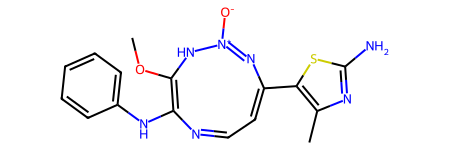

In [313]:
Chem.MolFromSmiles('Cc1nc(N)sc1-c1ccnc(Nc2ccccc2)c(OC)[nH]n(=O)n1')

In [293]:
cdk2_example['node'] = list(resps.argmax(axis=1))

In [306]:
resps[130].max()

np.float64(0.6062423505917499)

In [297]:
cdk2_example[cdk2_example['node'] == 130]

,canonical_smiles,id,act,node
947,Cc1nc(N)sc1-c1ccnc(Nc2cccc(c2)[N+]([O-])=O)n1,CHEMBL298445,8.7,130


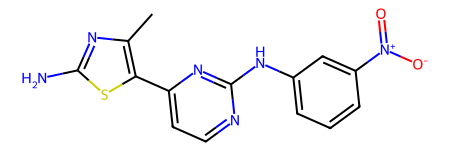

In [298]:
Chem.MolFromSmiles('Cc1nc(N)sc1-c1ccnc(Nc2cccc(c2)[N+]([O-])=O)n1')

In [225]:
Chem.MolFromSmiles('CC1ccc(C(=O)NC2CC(=O)Nc3ccc(F)c3cnc(C)c2)cn1')

[19:01:01] Can't kekulize mol.  Unkekulized atoms: 2 3 4 24 25


In [206]:
torch.from_numpy(nodes_coordinates[480].reshape(1, -1)).shape

torch.Size([1, 256])

In [236]:
# Try different temperature values
print("Effect of temperature on sampling diversity:\n")

for temp in [0.1, 0.5, 1.0, 10.5]:
    samples = sample_from_latent(model, z=z_test, n_samples=3, latent_std=1.0, temp=temp, decode='nogreedy')
    print(f"Temperature = {temp}")
    for i, smiles in enumerate(samples, 1):
        print(f"  {i}. {smiles}")
    print()


Effect of temperature on sampling diversity:

Temperature = 0.1
  1. N#CC1Cc2nc(Oc3ccc(N)cc3-c3ncnc3NCC2)n(N2CCCC2)C1=O

Temperature = 0.5
  1. N#CC1Cc2cnc(Nc3ccc(C)c3NC3CCCNC3)nc2N(C2CCCC2)C1=O

Temperature = 1.0
  1. N#CC1C=c2cnc(Nc3ccc(C)c3NC3CCCNC3)nc2N(C2CCCC2)C1=O

Temperature = 10.5
  1. [#=)C<bos>n2cBcsc1<pad>-cO(N-N3CC(C)l=C3F-nl)c3=C-3O



In [234]:
# Try different temperature values
print("Effect of temperature on sampling diversity:\n")

for temp in [0.1, 0.5, 1.0, 1.5]:
    samples = sample_from_latent(model, z=None, n_samples=3, latent_std=1.0, temp=temp)
    print(f"Temperature = {temp}")
    for i, smiles in enumerate(samples, 1):
        print(f"  {i}. {smiles}")
    print()


Effect of temperature on sampling diversity:



KeyboardInterrupt: 

In [12]:
z_test = encode_smiles(['CC(=O)Nc1ccc(O)cc1'], model, batch_size=1)

Encoding SMILES: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 180.93it/s]


In [13]:
reconstructed = model.sample(n_batch=1, z=torch.from_numpy(z_test), temp=0.00001, decode='greedy')

In [210]:
model.eval()
import torch

def _id2ch(vocab, tid):
    f = getattr(vocab, "id2char")
    return f(tid) if callable(f) else f[tid]

def _ch2id(vocab, ch):
    f = getattr(vocab, "char2id")
    return f(ch) if callable(f) else f[ch]

s = "CC(=O)Nc1ccc(O)cc1"
x = model.string2tensor(s)                       # BOS...EOS on model.device
z = model.forward_encoder([x])                   # (1, d_z)
print(z.shape, z.type())
# init decoder state exactly like your forward/sample
z_norm = model.decoder_lat_bn(z) if model.decoder_lat_bn is not None else z
h0 = [model.decoder_h0_layer1(z_norm)]
c0 = [model.decoder_c0_layer1(z_norm)]
if model.config.d_n_layers >= 2:
    h0 += [model.decoder_h0_layer2(z_norm)]
    c0 += [model.decoder_c0_layer2(z_norm)]
state = (torch.stack(h0, 0), torch.stack(c0, 0))  # (layers, 1, hidden)

toks = model.vocabulary.string2ids(s, add_bos=True, add_eos=True)
w = torch.tensor([toks[0]], device=model.device)  # <bos>
z_0 = z.unsqueeze(1)

with torch.no_grad():
    for i in range(1, len(toks)):
        x_emb = model.x_emb(w).unsqueeze(1)
        x_inp = torch.cat([x_emb, z_0], dim=-1)
        o, state = model.decoder_rnn(x_inp, state)
        logits = model.decoder_fc(o.squeeze(1))    # (1, vocab)
        gold = toks[i]

        if _id2ch(model.vocabulary, gold) == 'N':
            vals, idx = logits.squeeze(0).topk(8)
            top_tokens = [_id2ch(model.vocabulary, j.item()) for j in idx]
            print("Top@N step:", top_tokens, vals.tolist())
            break

        # teacher-force next gold token
        w = torch.tensor([gold], device=model.device)


torch.Size([1, 256]) torch.cuda.FloatTensor
Top@N step: ['c', 'N', 'S', 'O', '-', 'B', ']', 'r'] [19.282434463500977, 15.540168762207031, 8.838202476501465, 8.574742317199707, 2.3181557655334473, 1.4832696914672852, 0.06335163116455078, -3.5016188621520996]


In [211]:
z

tensor([[ 1.6697e-01, -2.7568e-01, -3.6817e-01, -4.0443e-02,  4.6969e-01,
          3.3876e-02, -2.0639e-01,  1.5673e-01, -3.0608e-01, -3.5330e-02,
         -2.8049e-01,  1.4780e-01, -5.3128e-01, -4.5199e-01,  4.1750e-01,
         -7.0388e-01,  4.7981e-01, -1.1537e-01,  8.1956e-01,  1.9026e-01,
         -1.8411e-01,  2.6456e-01, -4.7246e-01,  6.8685e-01, -2.7815e-01,
          5.2917e-01, -3.0394e-02, -4.4994e-01, -1.9352e-01,  9.7296e-02,
          4.4010e-01,  2.6953e-01, -5.8715e-01, -6.7495e-02, -4.2544e-01,
          7.0624e-02,  5.1353e-01, -3.7185e-01,  1.9098e-01,  4.5352e-01,
          1.9628e-01,  1.4901e-01,  4.2747e-01,  3.9144e-01,  7.3251e-01,
         -1.5316e-01, -8.7158e-01, -6.1218e-01,  1.0267e-01, -6.0715e-01,
          2.9428e-01,  3.4798e-01,  5.3481e-01, -1.0654e+00,  1.9580e-01,
          3.1551e-01,  1.4111e-01,  2.3709e-01, -1.8153e-01, -1.0910e-01,
         -3.4266e-01,  3.5546e-01,  5.7113e-03, -1.0047e-01, -1.7189e-01,
         -2.7064e-01, -1.7379e+00, -4.

## 6. Example: Reconstruct SMILES (Encode → Decode)


In [212]:
# Test reconstruction on known drug molecules
test_smiles = [
    "CC(C)Cc1ccc(C(C)C(=O)O)cc1",     # Ibuprofen
    "CC(=O)Oc1ccccc1C(=O)O",           # Aspirin
    'CC(=O)Nc1ccc(O)cc1',
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",    # Caffeine
    "CC(C)NCC(O)COc1ccccc1",           # Propranolol
    "CN1CCC23c4c5ccc(O)c4OC2C(O)C=CC3C1C5",  # Morphine
    "Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1" #celecoxib
]

print("Test molecules for reconstruction:\n")
for i, smiles in enumerate(test_smiles, 1):
    print(f"{i}. {smiles}")


Test molecules for reconstruction:

1. CC(C)Cc1ccc(C(C)C(=O)O)cc1
2. CC(=O)Oc1ccccc1C(=O)O
3. CC(=O)Nc1ccc(O)cc1
4. CN1C=NC2=C1C(=O)N(C(=O)N2C)C
5. CC(C)NCC(O)COc1ccccc1
6. CN1CCC23c4c5ccc(O)c4OC2C(O)C=CC3C1C5
7. Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1


In [213]:
z_test = encode_smiles(test_smiles, model, batch_size=len(test_smiles))

Encoding SMILES: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 57.07it/s]


In [216]:
z_test

array([[ 0.04648512, -0.11562067,  0.18174326, ..., -0.4063228 ,
         0.31031016,  0.07126982],
       [-0.00532485, -0.17072651, -0.40985513, ..., -0.13463442,
         0.56931514,  0.93318   ],
       [ 0.16696751, -0.275678  , -0.36816528, ..., -0.24979693,
         0.8129267 , -0.0748736 ],
       ...,
       [-0.06617332,  0.07558542, -0.22887163, ...,  0.45052046,
        -0.03529022, -0.64326525],
       [-0.36055323, -0.5153455 , -0.2641619 , ...,  0.16592784,
         0.08674277, -0.23011015],
       [ 0.1994254 , -0.02883382, -0.18225175, ...,  0.14320883,
        -0.12511192, -0.40263167]], shape=(7, 256), dtype=float32)

In [15]:
# Encode test molecules
z_test = encode_smiles(test_smiles, model, batch_size=len(test_smiles))

# Decode with low temperature for deterministic reconstruction
reconstructed = sample_from_latent(model, z=z_test, temp=0.1, decode='greedy')

print("\n" + "="*80)
print("Reconstruction Results (temp=0.1 for deterministic decoding)")
print("="*80 + "\n")

for i, (original, recon) in enumerate(zip(test_smiles, reconstructed), 1):
    match = "✓" if original == recon else "✗"
    print(f"{i}. {match}")
    print(f"   Original:      {original}")
    print(f"   Reconstructed: {recon}")
    print()


Encoding SMILES: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 58.77it/s]


Reconstruction Results (temp=0.1 for deterministic decoding)

1. ✓
   Original:      CC(C)Cc1ccc(C(C)C(=O)O)cc1
   Reconstructed: CC(C)Cc1ccc(C(C)C(=O)O)cc1

2. ✓
   Original:      CC(=O)Oc1ccccc1C(=O)O
   Reconstructed: CC(=O)Oc1ccccc1C(=O)O

3. ✗
   Original:      CC(=O)Nc1ccc(O)cc1
   Reconstructed: CC(=O)c1ccc(O)cc1

4. ✓
   Original:      CN1C=NC2=C1C(=O)N(C(=O)N2C)C
   Reconstructed: CN1C=NC2=C1C(=O)N(C(=O)N2C)C

5. ✓
   Original:      CC(C)NCC(O)COc1ccccc1
   Reconstructed: CC(C)NCC(O)COc1ccccc1

6. ✓
   Original:      CN1CCC23c4c5ccc(O)c4OC2C(O)C=CC3C1C5
   Reconstructed: CN1CCC23c4c5ccc(O)c4OC2C(O)C=CC3C1C5

7. ✓
   Original:      Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1
   Reconstructed: Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1



## 7. Example: Interpolate Between Molecules


In [17]:
# Interpolate between Aspirin and Caffeine
#smiles_1 = "CC(=O)Oc1ccccc1C(=O)O"           # Aspirin
smiles_1 = "CC(=O)Nc1ccc(O)cc1"           # Aspirin
#smiles_2 = "CN1C=NC2=C1C(=O)N(C(=O)N2C)C"    # Caffeine
smiles_2 = "Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1"    # Caffeine

# Encode both molecules
z1 = encode_smiles([smiles_1], model, batch_size=1)
z2 = encode_smiles([smiles_2], model, batch_size=1)

print(f"Molecule 1 (Aspirin): {smiles_1}")
print(f"Molecule 2 (Caffeine): {smiles_2}")
print(f"\nLatent vector distance: {np.linalg.norm(z1 - z2):.4f}")


Encoding SMILES: 100%|████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00, 217.76it/s]

Molecule 1 (Aspirin): CC(=O)Nc1ccc(O)cc1
Molecule 2 (Caffeine): Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2)cc1

Latent vector distance: 12.9268


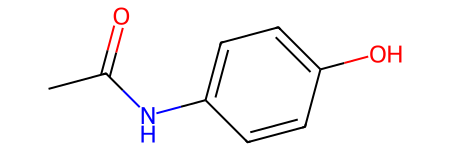

In [18]:
Chem.MolFromSmiles(smiles_1)

In [19]:
def interpolate(source_latent, dest_latent, steps):
    step = (dest_latent - source_latent) / float(steps)
    results = []
    for i in range(steps):
        item = source_latent + (step * i)        
        decoded = decode_latent_molecule(item, model, charset, latent_dim)
        results.append(decoded)
    return results

In [58]:
# Linear interpolation in latent space
n_steps = 300
alphas = np.linspace(0, 1, n_steps)

z_interp = []
step = (z2 - z1) / float(n_steps)
#for alpha in alphas:
#    z = (1 - alpha) * z1 + alpha * z2
#    z_interp.append(z)
for i in range(n_steps):
    item = z1 + (step * i)  
    z_interp.append(item)

z_interp = np.vstack(z_interp)

# Decode interpolated latent vectors
interpolated_smiles = sample_from_latent(model, z=z_interp, temp=0.1, decode='greedy')

print(f"\nInterpolation from Aspirin to Caffeine ({n_steps} steps):\n")
mols = []
legends = []
for i, (alpha, smiles) in enumerate(zip(alphas, interpolated_smiles)):
    print(f"α={alpha:.2f} | {smiles}")
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            mols.append(mol)
            legends.append(str(alpha))
    except:
        pass

TypeError: LSTMAutoencoder.sample() got an unexpected keyword argument 'decode'

In [21]:
mols

/data/aorlov/ChemEidos/.venv/lib/python3.11/site-packages/rdkit/Chem/Draw/IPythonConsole.py:343: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


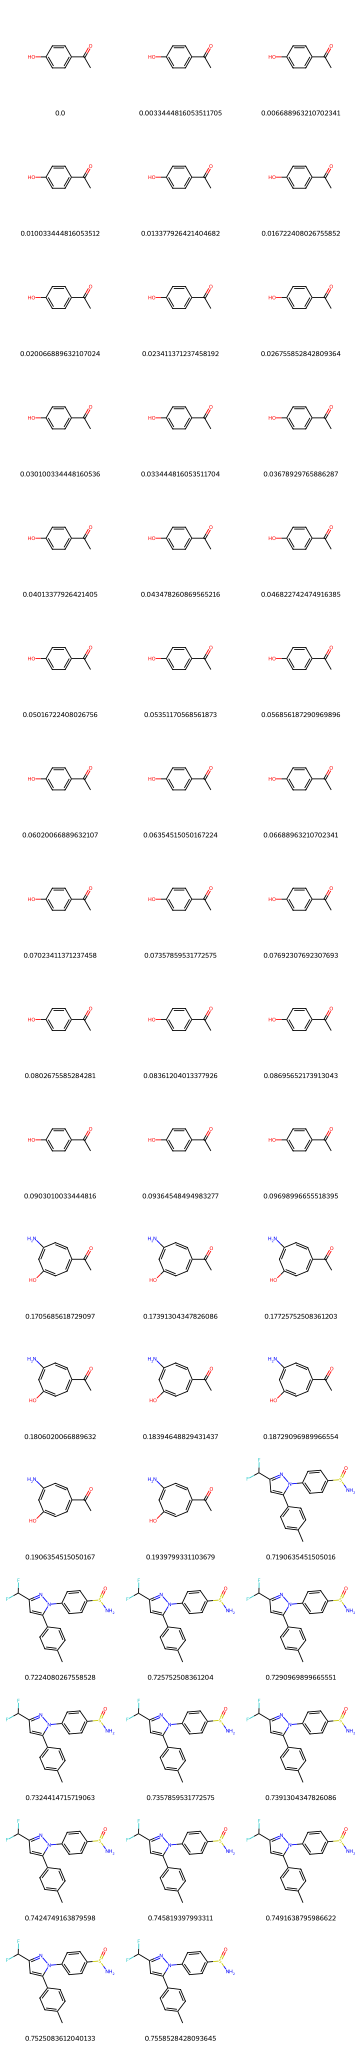

In [22]:
from rdkit.Chem import Draw

img2 = Draw.MolsToGridImage(
    mols=mols,
    legends=legends,
    molsPerRow=3,          # multiple columns; rows are filled automatically
    subImgSize=(280, 280),
    useSVG=True
)

display(img2)

# Selecting frameset

In [82]:
train = pd.read_csv('/data/aorlov/ChemEidos/data/train.csv')

In [83]:
train.head()

,SMILES,SPLIT
0,CCCS(=O)c1ccc2[nH]c(=NC(=O)OC)[nH]c2c1,train
1,CC(C)(C)C(=O)C(Oc1ccc(Cl)cc1)n1ccnc1,train
2,Cc1c(Cl)cccc1Nc1ncccc1C(=O)OCC(O)CO,train
3,Cn1cnc2c1c(=O)n(CC(O)CO)c(=O)n2C,train
4,CC1Oc2ccc(Cl)cc2N(CC(O)CO)C1=O,train


In [84]:
cdk2_example

,canonical_smiles,id,act
0,COc1cc(cc(OC)c1OC)C1=C(CNC1=O)c1cn(COC(C)(C)C)...,CHEMBL488646,4.64
1,Fc1ccc2NC(=O)C(=Cc3[nH]cc4c3CCNC4=O)c2c1,CHEMBL293113,6.52
2,Cc1ccc2n(CCc3c[nH]c4ccccc34)ccc2c1,CHEMBL556095,3.30
3,CNc1nc(C)c(s1)-c1ccnc(Nc2cccc(O)c2)n1,CHEMBL44119,6.96
4,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)c1c(F)cccc1F,CHEMBL191003,8.17
...,...,...,...
1784,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(n2)N(CCCC(F)(F)F...,CHEMBL419720,6.70
1785,CCCC(=O)Nc1n[nH]c2nc3ccccc3cc12,CHEMBL1967564,6.20
1786,CNS(=O)(=O)c1ccc2NC(=O)C(=Cc3[nH]cc4c3CCOC4=O)...,CHEMBL60541,8.40
1787,CCC(Nc1nc(NCc2cccc(C)n2)c2ncn(C(C)C)c2n1)C(C)O,CHEMBL3655773,7.30


In [85]:
train.shape

(1584663, 2)

In [86]:
train_50k = train.sample(50000)

In [15]:
train_50k.to_csv('../data/gtm_frameset_training.csv', index=False)

# Encoding them

In [87]:

print(f"\nEncoding {len(train_50k['SMILES'])} sample SMILES...")
sample_latents = encode_smiles(train_50k['SMILES'], model)
print(f"Encoded to latent vectors of shape: {sample_latents.shape}")



Encoding 50000 sample SMILES...


Encoding SMILES: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1563/1563 [00:09<00:00, 159.74it/s]


Encoded to latent vectors of shape: (50000, 256)


# Building the GTM on the frameset

In [17]:
sample_latents

array([[-0.2499375 ,  0.5728272 , -0.70606136, ..., -0.17307535,
         0.3795782 , -0.4913964 ],
       [ 0.31002888, -0.39517847,  0.35127857, ..., -0.08354002,
        -0.03157922, -0.5056026 ],
       [-0.19460261, -0.18608925,  0.20657542, ..., -0.31441242,
        -0.24896017, -0.8109318 ],
       ...,
       [ 0.39901504,  0.13817686, -0.5053042 , ..., -0.08130737,
         0.40593866, -0.12658048],
       [ 0.43035135,  0.32489622, -0.10905056, ..., -0.00709961,
         0.06487185,  0.61247236],
       [-0.12992793, -0.26388055, -0.19366956, ..., -0.34380418,
         0.33689263,  0.25005367]], shape=(50000, 256), dtype=float32)

In [18]:
np.unique(sample_latents, axis=0).shape

(50000, 256)

In [39]:
N_TRIALS_MAX = 300
N_NODES_SQRT_RANGE = (30, 50)
N_NODES_N_BASIS_DIFF_RANGE = (15, 25)
BASIS_WIDTH_RANGE = (1, 10.0)
REG_COEFF_RANGE = (1, 1000.0)
MAX_ITER = 200
N_STARTUP_TRIALS = 20

In [15]:
optimizer = GTMOptimizer(
    # GTM parameter ranges
    n_nodes_sqrt_range=N_NODES_SQRT_RANGE,
    n_nodes_n_basis_diff_range=N_NODES_N_BASIS_DIFF_RANGE,
    basis_width_range=BASIS_WIDTH_RANGE,
    reg_coeff_range=REG_COEFF_RANGE,
    max_iter=MAX_ITER,
    # Enhanced Optuna TPE sampler controls
    n_startup_trials=N_STARTUP_TRIALS,      # 15 random trials before TPE starts
)


In [18]:
X_pairwise_euclidean_mat = euclidean_distance_square_numba(sample_latents, sample_latents)

In [ ]:

results = optimizer.optimize_entropy(
    X=sample_latents,                            
    n_trials=N_TRIALS_MAX,                 # Number of optimization trials
    n_jobs=10                     # Parallel jobs (set to -1 for all cores)
)

In [119]:
gtm = GTM(
    num_nodes=900,              # 15 x 15
    num_basis_functions=225,    # 10 x 10
    basis_width=4,
    reg_coeff=500,
    device='cuda',
    standardize=False,           # enable internal standardization
    pca_scale=True,
    pca_engine="torch",
    max_iter=200,
)

#logger.info("Fitting GTM on %d samples of dim %d", X.shape[0], X.shape[1])
#gtm.fit(torch.from_numpy(X_scaled).double())
gtm.fit(torch.from_numpy(sample_latents).double())

  0%|          | 0/200 [00:00<?, ?it/s]

2025-12-04 16:26:14,944 - root - INFO - LLh: -237.54934 deltaLLh: 237.54934 beta: 1.13328
2025-12-04 16:26:15,404 - root - INFO - LLh: -90.22935 deltaLLh: 147.31999 beta: 8.30782
2025-12-04 16:26:15,872 - root - INFO - LLh: -87.48502 deltaLLh: 2.74433 beta: 8.68299
2025-12-04 16:26:16,340 - root - INFO - LLh: -84.3082 deltaLLh: 3.17682 beta: 8.95688
2025-12-04 16:26:16,803 - root - INFO - LLh: -82.21985 deltaLLh: 2.08835 beta: 9.19721
2025-12-04 16:26:17,309 - root - INFO - LLh: -81.1567 deltaLLh: 1.06315 beta: 9.32843
2025-12-04 16:26:17,814 - root - INFO - LLh: -80.55371 deltaLLh: 0.60299 beta: 9.39707
2025-12-04 16:26:18,294 - root - INFO - LLh: -80.16487 deltaLLh: 0.38883 beta: 9.43899
2025-12-04 16:26:18,788 - root - INFO - LLh: -79.90533 deltaLLh: 0.25955 beta: 9.46664
2025-12-04 16:26:19,242 - root - INFO - LLh: -79.72289 deltaLLh: 0.18244 beta: 9.48561
2025-12-04 16:26:19,701 - root - INFO - LLh: -79.59001 deltaLLh: 0.13288 beta: 9.49926
2025-12-04 16:26:20,161 - root - INFO - 

In [57]:
optimize_dataset(sample_latents, n_trials_max=50,
        k_hit=50)

[I 2025-10-07 17:00:46,779] A new study created in memory with name: no-name-5f0705c0-3916-4733-8211-88361948528e
[W 2025-10-07 17:00:46,780] Trial 0 failed with parameters: {} because of the following error: NameError("name 'get_gpu_for_trial' is not defined").
Traceback (most recent call last):
  File "/data/aorlov/ChemEidos/.venv/lib/python3.11/site-packages/optuna/study/_optimize.py", line 201, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_19946/3412389569.py", line 35, in objective
    device = get_gpu_for_trial(trial_number)
             ^^^^^^^^^^^^^^^^^
NameError: name 'get_gpu_for_trial' is not defined
[W 2025-10-07 17:00:46,783] Trial 0 failed with value None.


Launching optimization using 1 GPUs...


NameError: name 'get_gpu_for_trial' is not defined

In [107]:
X_scaled = sample_latents

In [182]:
nodes_coordinates[130]

array([-2.25441007e-02, -1.33708034e-01,  3.87555470e-02,  8.79296712e-02,
       -1.38167508e-01,  2.27756607e-02,  1.96282596e-01, -3.63950232e-02,
        8.88862852e-02, -3.82645187e-02,  5.44011685e-02, -2.93207573e-02,
       -7.24828899e-03, -1.60106355e-01,  6.51803214e-02,  8.99261840e-02,
        7.40367116e-02,  1.73503179e-01,  3.47457914e-02,  7.95577779e-02,
        1.51241723e-01,  3.07848731e-02, -8.87083277e-02,  8.13174362e-02,
       -1.22708861e-02, -2.59175156e-02,  1.15321921e-02, -1.80237550e-03,
       -3.52117886e-02,  4.51275043e-03,  8.97257664e-02, -2.03144774e-02,
        2.21578995e-01,  3.40275212e-02, -7.62459580e-02,  4.97426897e-03,
       -7.48573377e-02,  8.17319465e-03, -6.95910735e-03,  8.75722845e-02,
        4.84919580e-02, -4.71024534e-02,  9.75171362e-02, -1.57154790e-02,
        3.47079689e-01, -1.85218081e-01, -6.28248150e-03,  1.24296745e-02,
        1.06203742e-01,  1.01223422e-02, -4.75972887e-02, -7.78939078e-02,
       -7.07028953e-02,  

In [123]:
eigenvectors, eigenvalues = gtm._get_pca(torch.from_numpy(X_scaled.astype(np.float64)))
nodes_coordinates = gtm.phi @ gtm.weights
nodes_coordinates_pca3 = nodes_coordinates @ eigenvectors.T
latent_space_pca3 = torch.from_numpy(X_scaled).double().to('cuda') @ eigenvectors.T
#ref_latent_space_pca3 = torch.from_numpy(X_scaled).double().to('cuda') @ eigenvectors.T
nodes_coordinates = nodes_coordinates.cpu().numpy()
#Ev
import plotly.graph_objects as go
import torch
import plotly.io as pio
pio.renderers.default = 'browser'
# Assuming you already have your tensors on CUDA
try:
    nodes_coordinates_pca3 = nodes_coordinates_pca3.cpu().numpy()
except:
    pass
try:
    latent_space_pca3 = latent_space_pca3.cpu().numpy()
 #   ref_latent_space_pca3 = ref_latent_space_pca3.cpu().numpy()
except:
    pass

# Create the red grid — we'll plot it as a mesh3d or lines
# Red grid (connected with lines + markers)
grid_trace = go.Scatter3d(
    x=nodes_coordinates_pca3[:, 0],
    y=nodes_coordinates_pca3[:, 1],
    z=nodes_coordinates_pca3[:, 2],
    mode='lines+markers',
    #mode='markers',
    marker=dict(size=3, color='red'),
    #line=dict(color='red', width=3),
    name=''
)

hover_labels_trace = go.Scatter3d(
    x=nodes_coordinates_pca3[:, 0],
    y=nodes_coordinates_pca3[:, 1],
    z=nodes_coordinates_pca3[:, 2],
    mode='markers',
    marker=dict(size=3, color='red'),
    text=[f"Node {i}" for i in range(len(nodes_coordinates_pca3))],
    hoverinfo='text',
    showlegend=False
)


points_trace = go.Scatter3d(
    x=latent_space_pca3[:, 0],
    y=latent_space_pca3[:, 1],
    z=latent_space_pca3[:, 2],
    mode="markers",
    marker=dict(
        size=1,
        color='black',                  # numeric array for coloring
        #colorscale=['black', 'orange', 'green', 'blue', 'magenta'],          # or any named colorscale
        #colorbar=dict(title='Value'),  # shows scale legend on plot
    ),
    name=""
)
"""

ref_pca3 = go.Scatter3d(
    x=ref_latent_space_pca3[:, 0],
    y=ref_latent_space_pca3[:, 1],
    z=ref_latent_space_pca3[:, 2],
    mode="markers",
    marker=dict(
        size=2,
        color='blue',                  # numeric array for coloring
        #colorscale=['black', 'orange', 'green', 'blue', 'magenta'],          # or any named colorscale
        #colorbar=dict(title='Value'),  # shows scale legend on plot
    ),
    name=""
)
"""
# Combine into a figure
fig = go.Figure(data=[grid_trace, points_trace, hover_labels_trace])
#fig = go.Figure(data=[del_pca3])
#fig = go.Figure(data=[grid_trace, points_trace])

# Update layout for better visuals
fig.update_layout(
    scene=dict(
        xaxis_title='PCA 1',
        yaxis_title='PCA 2',
        zaxis_title='PCA 3'
    ),
    title='3D PCA Space Visualization',
    width=800,
    height=800
)

# Show the interactive plot
fig.write_html("manifold_3d_seq2seq_SMILES_900_225_4_500.html", auto_open=True)
#fig.show()


Gtk-Message: 16:41:59.749: Not loading module "atk-bridge": The functionality is provided by GTK natively. Please try to not load it.
[4100241, Main Thread] WARNING: GTK+ module /snap/firefox/7423/gnome-platform/usr/lib/gtk-2.0/modules/libcanberra-gtk-module.so cannot be loaded.
GTK+ 2.x symbols detected. Using GTK+ 2.x and GTK+ 3 in the same process is not supported.: 'glib warning', file /build/firefox/parts/firefox/build/toolkit/xre/nsSigHandlers.cpp:201

(firefox_firefox:4100241): Gtk-WARNING **: 16:41:59.950: GTK+ module /snap/firefox/7423/gnome-platform/usr/lib/gtk-2.0/modules/libcanberra-gtk-module.so cannot be loaded.
GTK+ 2.x symbols detected. Using GTK+ 2.x and GTK+ 3 in the same process is not supported.
Gtk-Message: 16:41:59.950: Failed to load module "canberra-gtk-module"
[4100241, Main Thread] WARNING: GTK+ module /snap/firefox/7423/gnome-platform/usr/lib/gtk-2.0/modules/libcanberra-gtk-module.so cannot be loaded.
GTK+ 2.x symbols detected. Using GTK+ 2.x and GTK+ 3 in th

In [124]:
import pickle
with open('../data/GTM_manifold_900_225_4_500.pkl.gz', 'wb') as f:
    pickle.dump(gtm, f)

In [110]:
cdk2_example_latents = cdk2_example

# GTM analysis

In [125]:
import pickle
with open('../data/GTM_manifold_900_225_4_500.pkl.gz', 'rb') as f:
#with open('../data/GTM_manifold_900_225_8_100.pkl.gz', 'rb') as f:
#with open('../data/GTM_manifold_900_100_6_100.pkl.gz', 'rb') as f:
    gtm = pickle.load(f)

In [63]:
cdk2_example = pd.read_csv('~/Downloads/chembl_CDK2_kinase.csv', sep=",")

In [139]:
cdk2_example = pd.read_csv('~/Downloads/CHEMBL301.smi_chid_pX', names=['canonical_smiles', 'id', 'act'], sep=" ")

In [140]:
cdk2_example

,canonical_smiles,id,act
0,COc1cc(cc(OC)c1OC)C1=C(CNC1=O)c1cn(COC(C)(C)C)...,CHEMBL488646,4.64
1,Fc1ccc2NC(=O)C(=Cc3[nH]cc4c3CCNC4=O)c2c1,CHEMBL293113,6.52
2,Cc1ccc2n(CCc3c[nH]c4ccccc34)ccc2c1,CHEMBL556095,3.30
3,CNc1nc(C)c(s1)-c1ccnc(Nc2cccc(O)c2)n1,CHEMBL44119,6.96
4,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)c1c(F)cccc1F,CHEMBL191003,8.17
...,...,...,...
1784,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(n2)N(CCCC(F)(F)F...,CHEMBL419720,6.70
1785,CCCC(=O)Nc1n[nH]c2nc3ccccc3cc12,CHEMBL1967564,6.20
1786,CNS(=O)(=O)c1ccc2NC(=O)C(=Cc3[nH]cc4c3CCOC4=O)...,CHEMBL60541,8.40
1787,CCC(Nc1nc(NCc2cccc(C)n2)c2ncn(C(C)C)c2n1)C(C)O,CHEMBL3655773,7.30


In [126]:
cdk2_example = pd.read_csv('~/Documents/cdk2_man.csv', sep=",")

/tmp/ipykernel_3868245/2821645176.py:1: DtypeWarning:

Columns (169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,289,290,291,292,293,294,295,296,297,298,299,300,301,302,303,304,305,306,307,308,309,310,311,312,313,314,315,316,317,318,319,320,321,322,323,324,325,326,327,328,329,330,331,332,333,334,335,336,337,338,339,340,341,342,343,344,345,346,347,348,349,350,351,352,353,354,355,356,357,358,359,360,361,362,363,364,365,366,367,368,369,370,371,372,373,375,376,377,378,379,380,381,383,384,385,386,387,388,390,391,392,394,395,396,398,399,400,401,403,404,405,407,408,409,

In [121]:
cdk2_example.columns

Index(['ChEMBL ID', 'Name', 'Synonyms', 'Type', 'Max Phase',
       'Molecular Weight', 'Targets', 'Bioactivities', 'AlogP',
       'Polar Surface Area',
       ...
       'Unnamed: 870', 'Unnamed: 871', 'Unnamed: 872', 'Unnamed: 873',
       'Unnamed: 874', 'Unnamed: 875', 'Unnamed: 876', 'Unnamed: 877',
       'Unnamed: 878', 'canonical_smiles'],
      dtype='object', length=880)

In [127]:
cdk2_example['canonical_smiles'] =cdk2_example['Smiles']  
cdk2_example = cdk2_example[~cdk2_example['canonical_smiles'].isna()]

In [128]:
from rdkit import Chem
cdk2_example['canonical_smiles'] = cdk2_example['canonical_smiles'].apply(lambda x: Chem.MolToSmiles(Chem.MolFromSmiles(x)))

In [129]:
cdk2_example.head()

,ChEMBL ID,Name,Synonyms,Type,Max Phase,Molecular Weight,Targets,Bioactivities,AlogP,Polar Surface Area,...,Unnamed: 870,Unnamed: 871,Unnamed: 872,Unnamed: 873,Unnamed: 874,Unnamed: 875,Unnamed: 876,Unnamed: 877,Unnamed: 878,canonical_smiles
0,CHEMBL2252445,1-hydroxy-2-butoxybenzene,NaN,Small molecule,NaN,166.22,1.0,4.0,2.57,29.46,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CCCCOc1ccccc1O
1,CHEMBL2229481,"2-Exo-hexoxy-1,4-cineole",NaN,Small molecule,NaN,268.40,2.0,16.0,3.85,35.53,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CCCCCC(=O)O[C@@H]1C[C@@]2(C(C)C)CC[C@@]1(C)O2
3,CHEMBL1201383,GEMCITABINE TRIPHOSPHATE,"2',2'-difluorodeoxycytidine 5'-triphosphate|DF...",Small molecule,-1.0,503.14,1.0,2.0,-0.94,250.19,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Nc1ccn([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)OP(=O)...
4,CHEMBL1791284,LISSOCLINAMIDE 2,NaN,Small molecule,NaN,679.87,1.0,1.0,2.90,154.45,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CC[C@@H](C)[C@H]1NC(=O)[C@H]2N=C(O[C@@H]2C)[C@...
5,CHEMBL2271808,N-(2-(4-BENZYLPHENOXY)ETHYL)-O-ISOBUTYLHYDROXY...,NaN,Small molecule,NaN,299.41,1.0,1.0,3.83,30.49,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,CC(C)CONCCOc1ccc(Cc2ccccc2)cc1


In [130]:
[col for col in cdk2_example.columns if 'smi' in col]

['canonical_smiles']

In [146]:
cdk2_smiles = np.unique(cdk2_example['canonical_smiles'].to_list())
cdk2_latents = encode_smiles(cdk2_smiles, model, batch_size=len(cdk2_smiles))

Encoding SMILES: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  5.85it/s]


In [147]:
cdk2_smiles

array(['BrC1=Cc2cnc(Nc3ccc(cc3)N3CCNCC3)nc2N(C2CCCC2)C1=O',
       'Brc1cc2c(NC(=O)C3CC3)n[nH]c2nc1-c1cccs1',
       'Brc1ccc(CC(=O)Nc2n[nH]c3ccc(cc23)N2CCCS2(=O)=O)cc1', ...,
       'c1cc2cc(cnc2[nH]1)-c1ccc2cn[nH]c2c1',
       'c1n[nH]c2ccc(cc12)-c1cn2cccnc2n1', 'c1n[nH]c2ccccc12'],
      shape=(1789,), dtype='<U100')

In [148]:
cdk2_latents.shape

(1789, 256)

In [149]:
fingerprint_tensor = torch.tensor(cdk2_latents, dtype=torch.float64, device=device)
resps, llh = gtm.project(fingerprint_tensor)
resps = resps.cpu().numpy()
llh = llh.cpu().numpy()

In [150]:
resps.sum(axis=0)

array([4.14577551e+01, 2.74550197e+00, 6.22972262e+00, 1.06285715e+00,
       6.90677911e-02, 5.32626708e-02, 1.46010266e-01, 2.77052010e-01,
       6.55583905e-01, 5.81335058e-01, 2.42341924e-01, 1.21488221e+00,
       2.46276954e+00, 1.63441496e+00, 4.33225862e+00, 6.06334910e+00,
       5.77328319e+00, 1.10281237e+01, 2.29242962e+01, 3.67550984e+01,
       5.54400009e+01, 5.10730792e+01, 4.09976375e+01, 3.13265154e+01,
       2.48205997e+01, 1.64427070e+01, 7.50317933e+00, 1.96199765e+00,
       1.74877734e+00, 3.14185197e+00, 1.93688712e+00, 6.98152742e-01,
       9.00112278e-01, 8.98580164e-01, 2.96853899e-01, 4.74029324e-01,
       8.84933266e-01, 1.67589806e+00, 1.37490710e+00, 3.29303359e-01,
       3.15858862e-01, 3.33173987e-01, 8.45297975e-01, 1.15714544e+00,
       5.78248026e-01, 9.55738636e-01, 1.68454231e+00, 2.46474970e+00,
       3.32963788e+00, 2.73119832e+00, 2.28771022e+00, 2.89407731e+00,
       2.00310061e+00, 2.67119071e+00, 3.08012879e+00, 3.08330100e+00,
      

In [ ]:
from gtmkit.plots.plotly_landscapes import plotly_smooth_regression_landscape, plotly_smooth_density_landscape


In [180]:
from gtmkit.utils.density import density_to_table
from gtmkit.plots.altair_landscapes import altair_discrete_density_landscape, altair_discrete_regression_landscape

density = resps.sum(axis=0)

source = density_to_table(
    density=density,
    node_threshold=0.5
)

chart_density = altair_discrete_density_landscape(source, title='Density landscape')
chart_density.properties(
    width=400, 
    height=400,
).configure_legend(
    labelFontSize=20,
    gradientVerticalMaxLength=600,
    gradientThickness=30,
    tickCount=6
)

alt.Chart(...)

In [178]:
density, reg_density = get_reg_density_matrix(resps_CDK2, cdk2_merged)
reg_table = reg_density_to_table(density, reg_density, node_threshold=0.5)
table = density_to_table(density, node_threshold=0.5)

#reg_landscape = plotly_smooth_regression_landscape(reg_table)
reg_chart = altair_discrete_regression_landscape(reg_table, colorset='viridis')

In [179]:
reg_chart

alt.Chart(...)

In [ ]:
density, reg_density = get_reg_density_matrix(resps_CDK2, cdk2_merged)
reg_table = reg_density_to_table(density, reg_density, node_threshold=1)
table = density_to_table(density, node_threshold=1)

reg_landscape = plotly_smooth_regression_landscape(reg_table)
dens_landscape = plotly_smooth_density_landscape(table, colorset=ChEMBLcolorset)

charts = []
charts.append(dens_landscape)
charts.append(reg_landscape)

all_charts_widget = [go.FigureWidget(fig) for fig in charts]
plotly_layout = widgets.HBox(all_charts_widget)
plotly_layout

In [158]:
cdk2_example

,canonical_smiles,id,act
0,COc1cc(cc(OC)c1OC)C1=C(CNC1=O)c1cn(COC(C)(C)C)...,CHEMBL488646,4.64
1,Fc1ccc2NC(=O)C(=Cc3[nH]cc4c3CCNC4=O)c2c1,CHEMBL293113,6.52
2,Cc1ccc2n(CCc3c[nH]c4ccccc34)ccc2c1,CHEMBL556095,3.30
3,CNc1nc(C)c(s1)-c1ccnc(Nc2cccc(O)c2)n1,CHEMBL44119,6.96
4,Nc1nc(Nc2ccc(cc2)S(N)(=O)=O)nn1C(=O)c1c(F)cccc1F,CHEMBL191003,8.17
...,...,...,...
1784,CN(C)CC(O)COc1ccc(Nc2ncc(Br)c(n2)N(CCCC(F)(F)F...,CHEMBL419720,6.70
1785,CCCC(=O)Nc1n[nH]c2nc3ccccc3cc12,CHEMBL1967564,6.20
1786,CNS(=O)(=O)c1ccc2NC(=O)C(=Cc3[nH]cc4c3CCOC4=O)...,CHEMBL60541,8.40
1787,CCC(Nc1nc(NCc2cccc(C)n2)c2ncn(C(C)C)c2n1)C(C)O,CHEMBL3655773,7.30


In [160]:
resps_CDK2 = resps 
cdk2_merged = cdk2_example.act.tolist()

In [169]:
from gtmkit.utils.regression import get_reg_density_matrix, reg_density_to_table
from gtmkit.plots.plotly_landscapes import plotly_smooth_regression_landscape, plotly_smooth_density_landscape

# Needed for plotply plots
import plotly.graph_objects as go
import ipywidgets as widgets
from ipywidgets import GridspecLayout, Box
ChEMBLcolorset = [
    [0.0000, 'rgb(255,255,255)'], [0.0100, 'rgb(255,255,255)'],
    [0.0100, 'rgb(160,160,160)'], [0.0571, 'rgb(160,160,160)'],
    [0.0571, 'rgb(126,126,126)'], [0.1042, 'rgb(126,126,126)'],
    [0.1042, 'rgb(71,71,71)'],    [0.1513, 'rgb(71,71,71)'],
    [0.1513, 'rgb(0,0,50)'],      [0.1984, 'rgb(0,0,50)'],
    [0.1984, 'rgb(30,22,135)'],   [0.2455, 'rgb(30,22,135)'],
    [0.2455, 'rgb(3,10,255)'],    [0.2926, 'rgb(3,10,255)'],
    [0.2926, 'rgb(2,103,255)'],   [0.3397, 'rgb(2,103,255)'],
    [0.3397, 'rgb(2,192,255)'],   [0.3868, 'rgb(2,192,255)'],
    [0.3868, 'rgb(3,255,174)'],   [0.4339, 'rgb(3,255,174)'],
    [0.4339, 'rgb(1,199,153)'],   [0.4810, 'rgb(1,199,153)'],
    [0.4810, 'rgb(18,122,21)'],   [0.5281, 'rgb(18,122,21)'],
    [0.5281, 'rgb(10,185,30)'],   [0.5752, 'rgb(10,185,30)'],
    [0.5752, 'rgb(42,255,4)'],    [0.6223, 'rgb(42,255,4)'],
    [0.6223, 'rgb(192,255,4)'],   [0.6694, 'rgb(192,255,4)'],
    [0.6694, 'rgb(255,255,0)'],   [0.7165, 'rgb(255,255,0)'],
    [0.7165, 'rgb(251,183,2)'],   [0.7636, 'rgb(251,183,2)'],
    [0.7636, 'rgb(255,116,2)'],   [0.8107, 'rgb(255,116,2)'],
    [0.8107, 'rgb(255,0,0)'],     [0.8578, 'rgb(255,0,0)'],
    [0.8578, 'rgb(214,0,0)'],     [0.9049, 'rgb(214,0,0)'],
    [0.9049, 'rgb(153,5,5)'],     [0.9520, 'rgb(153,5,5)'],
    [0.9520, 'rgb(100,0,0)'],     [1.0000, 'rgb(100,0,0)']
]

density, reg_density = get_reg_density_matrix(resps_CDK2, cdk2_merged)
reg_table = reg_density_to_table(density, reg_density, node_threshold=1)
table = density_to_table(density, node_threshold=1)

reg_landscape = plotly_smooth_regression_landscape(reg_table)
dens_landscape = plotly_smooth_density_landscape(table, colorset=ChEMBLcolorset)

charts = []
charts.append(dens_landscape)
charts.append(reg_landscape)

all_charts_widget = [go.FigureWidget(fig) for fig in charts]
plotly_layout = widgets.HBox(all_charts_widget)
plotly_layout

/data/aorlov/deepchemography/.venv/lib/python3.13/site-packages/jupyter_client/session.py:721: UserWarning:

Message serialization failed with:
Out of range float values are not JSON compliant: nan
Supporting this message is deprecated in jupyter-client 7, please make sure your message is JSON-compliant



    'data': [{'colorbar': {'title': {'text': 'Density'}},
              'colorsc…

In [54]:
source[]

,x,y,nodes,density,filtered_density
0,1,1,1,4.540443e-05,NaN
30,1,2,2,2.848831e-03,NaN
60,1,3,3,2.991821e-02,NaN
90,1,4,4,5.344682e-02,NaN
120,1,5,5,1.762054e-02,NaN
...,...,...,...,...,...
779,30,26,896,1.846456e-11,NaN
809,30,27,897,3.184735e-09,NaN
839,30,28,898,5.233149e-08,NaN
869,30,29,899,4.071896e-07,NaN


In [56]:
nodes_coordinates = gtm.phi @ gtm.weights
nodes_coordinates = nodes_coordinates.cpu().numpy()

In [58]:
nodes_coordinates.shape

(900, 256)

In [61]:
z_dense = nodes_coordinates[480]

In [64]:
from gtmkit.utils.density import density_to_table
from gtmkit.plots.altair_landscapes import altair_discrete_density_landscape

density = resps.sum(axis=0)

source = density_to_table(
    density=density,
    node_threshold=0.1
)

chart_density = altair_discrete_density_landscape(source, title='Density landscape')
chart_density.properties(
    width=400, 
    height=400,
).configure_legend(
    labelFontSize=20,
    gradientVerticalMaxLength=600,
    gradientThickness=30,
    tickCount=6
)

alt.Chart(...)

In [65]:
source.to_csv('')

,x,y,nodes,density,filtered_density
0,1,1,1,197.250638,197.250638
30,1,2,2,114.291335,114.291335
60,1,3,3,116.050591,116.050591
90,1,4,4,130.796335,130.796335
120,1,5,5,140.529713,140.529713
...,...,...,...,...,...
779,30,26,896,127.813111,127.813111
809,30,27,897,162.691138,162.691138
839,30,28,898,186.887888,186.887888
869,30,29,899,198.904425,198.904425


In [35]:
from gtmkit.utils.density import density_to_table
from gtmkit.plots.altair_landscapes import altair_discrete_density_landscape

density = resps.sum(axis=0)

source = density_to_table(
    density=density,
    node_threshold=0.1
)

chart_density = altair_discrete_density_landscape(source, title='Density landscape')
chart_density.properties(
    width=400, 
    height=400,
).configure_legend(
    labelFontSize=20,
    gradientVerticalMaxLength=600,
    gradientThickness=30,
    tickCount=6
)

alt.Chart(...)

## 8. Example: Explore Latent Space Neighborhoods


In [ ]:
# Pick a base molecule and explore its neighborhood
base_smiles = "CC(=O)Oc1ccccc1C(=O)O"  # Aspirin
z_base = encode_smiles([base_smiles], model, batch_size=1)

print(f"Base molecule: {base_smiles}\n")
print("Exploring latent space neighborhood with different noise scales:\n")


In [64]:
z_base = z_dense.reshape(1, -1)

In [82]:
import numpy as np
import pandas as pd
from rdkit import Chem

rows = []  # will hold dicts for the DataFrame

# Treat noise_scale as the "distance"
for distance in [0.05, 0.08, 0.11, 0.14, 0.17]:#, 0.1, 0.2, 0.5]:
    n_neighbors = 100
    z_neighbors = z_base + np.random.randn(n_neighbors, z_base.shape[1]) * distance
    neighbors = sample_from_latent(model, z=z_neighbors, temp=0.5)

    for i, neighbor in enumerate(neighbors, 1):
        mol = Chem.MolFromSmiles(neighbor)
        if mol:
            rows.append({
                "distance": distance,
                "neighbor_idx": i,
                "smiles": Chem.MolToSmiles(mol)  # canonicalized
            })

# DataFrame with one row per neighbor
df = pd.DataFrame(rows).sort_values(["distance", "neighbor_idx"]).reset_index(drop=True)

# Optional: list of SMILES per distance (useful for quick lookups)
df_grouped = (df.groupby("distance", as_index=False)
                .agg(smiles_list=("smiles", list),
                     n_valid=("smiles", "size"))
             )

# Examples of how to use it:
# 1) All neighbors for distance=0.1
# df[df["distance"] == 0.1]

# 2) Unique SMILES per distance
# df_unique = df.drop_duplicates(subset=["distance", "smiles"])
# df_unique[df_unique["distance"] == 0.1]["smiles"].tolist()

# 3) Quick peek
# print(df.head())
# print(df_grouped)


[17:03:58] Can't kekulize mol.  Unkekulized atoms: 13 14 15 17 18
[17:03:58] SMILES Parse Error: extra close parentheses while parsing: Cc1ccc(C(=O)N2CCN(C)c3cc(C(=O)NC)c3C)C2)cn1
[17:03:58] SMILES Parse Error: check for mistakes around position 40:
[17:03:58] )c3cc(C(=O)NC)c3C)C2)cn1
[17:03:58] ~~~~~~~~~~~~~~~~~~~~^
[17:03:58] SMILES Parse Error: Failed parsing SMILES 'Cc1ccc(C(=O)N2CCN(C)c3cc(C(=O)NC)c3C)C2)cn1' for input: 'Cc1ccc(C(=O)N2CCN(C)c3cc(C(=O)NC)c3C)C2)cn1'
[17:03:58] Can't kekulize mol.  Unkekulized atoms: 14 15 16 18 19
[17:03:58] Can't kekulize mol.  Unkekulized atoms: 12 15 21
[17:03:58] SMILES Parse Error: unclosed ring for input: 'Cc1ccc(C(=O)N2CC(c3)cc(C(=O)Nc3ccc(C)n3)CC2)cn1'
[17:03:58] Can't kekulize mol.  Unkekulized atoms: 12 13 14 17 18
[17:03:58] Can't kekulize mol.  Unkekulized atoms: 10 23
[17:03:58] SMILES Parse Error: extra close parentheses while parsing: Cc1ccc(C(=O)N2CCN(C)c3cc(C(=O)NC)c3C)n2)co1
[17:03:58] SMILES Parse Error: check for mistakes around

In [92]:
df_grouped

,distance,smiles_list,n_valid
0,0.05,[Cc1ccc(C(=O)N2CC(=O)N(Cc3ccc(C)nc3C)C2)c(C)c1...,23
1,0.08,"[Cc1ccc(C(=O)N2CCC(c3nc(C)cc(C)n3)NC(C)C2)cn1,...",15
2,0.11,"[COc1ccc(N2CCN(C(=O)c3cnc(C)c(C)c3)C2)c(C)c1, ...",16
3,0.14,[Cc1cnc(NC(=O)CC2=NC(C3CCN(C)C(=O)C3)=C2)c(C)c...,9
4,0.17,"[CC1=CN(c2nc(C)ccc2C)CCN1C(=O)C(C)N1CCOC1, Cc1...",2


In [88]:
cdk2_example

,activity_comment,activity_id,assay_chembl_id,canonical_smiles,data_validity_comment,molecule_chembl_id,pchembl_value,potential_duplicate,standard_type,standard_units,standard_value,type,units,value,SMILES
0,NaN,512202,CHEMBL660706,Cc1cccc(Cl)c1NC(=O)c1cnc(NC(=O)C2CC2)s1,NaN,CHEMBL131577,NaN,0,IC50,nM,25000.0,IC50,uM,25.0,Cc1cccc(Cl)c1NC(=O)c1cnc(NC(=O)C2CC2)s1
1,NaN,512210,CHEMBL658934,Cc1cccc(Cl)c1NC(=O)c1cnc(NC(=O)C2CC2)s1,NaN,CHEMBL131577,NaN,0,Fold selectivity,NaN,700.0,Fold selectivity,NaN,700.0,Cc1cccc(Cl)c1NC(=O)c1cnc(NC(=O)C2CC2)s1
2,Active,1798737,CHEMBL907057,C[C@H]1[C@@H](CC(CNc2ccccc2)C[C@H]2O[C@@H]3O[C...,NaN,CHEMBL373822,NaN,0,Activity,NaN,NaN,Activity,NaN,NaN,C[C@H]1[C@@H](CC(CNc2ccccc2)C[C@H]2O[C@@H]3O[C...
3,Active,1798746,CHEMBL907057,CCOP(=O)(OCC)OCC(C[C@H]1O[C@@H]2O[C@@]3(C)CC[C...,NaN,CHEMBL375378,NaN,0,Activity,NaN,NaN,Activity,NaN,NaN,CCOP(=O)(OCC)OCC(C[C@H]1O[C@@H]2O[C@@]3(C)CC[C...
4,Active,1798747,CHEMBL907057,C[C@H]1[C@@H](CC(COP(=O)(Oc2ccccc2)Oc2ccccc2)C...,NaN,CHEMBL219245,NaN,0,Activity,NaN,NaN,Activity,NaN,NaN,C[C@H]1[C@@H](CC(COP(=O)(Oc2ccccc2)Oc2ccccc2)C...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
90,224877,17613398,CHEMBL3705130,CC(C)c1cc(NCc2ccncc2)n2ncc(Br)c2n1,NaN,CHEMBL3642651,7.38,0,IC50,nM,42.0,IC50,nM,42.0,CC(C)c1cc(NCc2ccncc2)n2ncc(Br)c2n1
91,224878,17613399,CHEMBL3705130,CC(C)(C)c1cc(NCc2ccncc2)n2ncc(Br)c2n1,NaN,CHEMBL3642652,6.77,0,IC50,nM,170.0,IC50,nM,170.0,CC(C)(C)c1cc(NCc2ccncc2)n2ncc(Br)c2n1
92,224879,17613400,CHEMBL3705130,N#Cc1cnn2c(NCc3ccncc3)cc(-c3ccccc3)nc12,NaN,CHEMBL3642653,6.21,0,IC50,nM,620.0,IC50,nM,620.0,N#Cc1cnn2c(NCc3ccncc3)cc(-c3ccccc3)nc12
93,224880,17613401,CHEMBL3705130,CN1CCN(c2cc(NCc3cccnc3)n3nccc3n2)CC1,NaN,CHEMBL3642654,5.25,0,IC50,nM,5600.0,IC50,nM,5600.0,CN1CCN(c2cc(NCc3cccnc3)n3nccc3n2)CC1


In [89]:
df.head(n=10)

,distance,neighbor_idx,smiles
0,0.05,3,Cc1ccc(C(=O)N2CC(=O)N(Cc3ccc(C)nc3C)C2)c(C)c1
1,0.05,10,Cc1ccc(C(=O)N2CC(C)N(Cc3ccc(C)nc3C)C2)cc1
2,0.05,22,Cc1ccc(C(=O)N2CC(C)N(Cc3ccc(C)nc3C)C2)cc1
3,0.05,26,Cc1ccc(CN2CN(c3c(C)cc(C)nc3C)CCC2=O)c(C)n1
4,0.05,31,Cc1ccc(C(=O)N2CC(=O)N(Cc3ccc(C)nc3C)C2)nc1
5,0.05,40,Cc1ccc(C(=O)N2CC(c3ccc(N(C)C)c(=O)nc3)C2)cn1
6,0.05,42,Cc1ccc(C(=O)N2CC(C)NC(c3cc(C)c(C)cn3)C2)cn1
7,0.05,45,Cc1cc(C)c(N2CC(=O)NC(c3cc(=O)oc(N)c3C)C2)cn1
8,0.05,47,CC1=C(CC(=O)N2CCN(C(=O)c3ccc(C)nc3C)CC2)N=C1
9,0.05,49,Cc1ccc(C(=O)N2CC(C)N(c3ccc(C)nc3)C(C)C2)cn1


In [84]:
df.shape

(65, 3)

In [85]:
df['smiles'].nunique()

56

In [32]:
#cdk2_smiles = df['smiles'].to_list()
cdk2_latents = encode_smiles(cdk2_smiles, model, batch_size=len(cdk2_smiles))
fingerprint_tensor = torch.tensor(cdk2_latents, dtype=torch.float64, device=device)
resps, llh = gtm.project(fingerprint_tensor)
resps = resps.cpu().numpy()
llh = llh.cpu().numpy()
from gtmkit.utils.density import density_to_table
from gtmkit.plots.altair_landscapes import altair_discrete_density_landscape

density = resps.sum(axis=0)

source = density_to_table(
    density=density,
    node_threshold=0.1
)

chart_density = altair_discrete_density_landscape(source, title='Density landscape')
chart_density.properties(
    width=400, 
    height=400,
).configure_legend(
    labelFontSize=20,
    gradientVerticalMaxLength=600,
    gradientThickness=30,
    tickCount=6
)

Encoding SMILES: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  4.83it/s]


alt.Chart(...)

## 9. Example: Latent Space Arithmetic


In [ ]:
# Try analogy: A - B + C (similar to word2vec)
# Example: Aspirin - Benzene + Ethanol = ?

smiles_A = "CC(=O)Oc1ccccc1C(=O)O"   # Aspirin (benzene ring + acetyl + carboxyl)
smiles_B = "c1ccccc1"                 # Benzene
smiles_C = "CCO"                      # Ethanol

z_A = encode_smiles([smiles_A], model, batch_size=1)
z_B = encode_smiles([smiles_B], model, batch_size=1)
z_C = encode_smiles([smiles_C], model, batch_size=1)

# Latent arithmetic: A - B + C
z_result = z_A - z_B + z_C

result_smiles = sample_from_latent(model, z=z_result, temp=0.5)

print("Latent Space Arithmetic: A - B + C")
print(f"\nA (Aspirin):  {smiles_A}")
print(f"B (Benzene):  {smiles_B}")
print(f"C (Ethanol):  {smiles_C}")
print(f"\nResult (A - B + C): {result_smiles[0]}")


## 10. Example: Save Encoded Vectors and Generated Samples


In [ ]:
# Save latent vectors to disk
output_file = '../samples_autoencoder_latent.npy'
np.save(output_file, latent_vectors)
print(f"✓ Saved latent vectors to {output_file}")
print(f"  Shape: {latent_vectors.shape}")


In [ ]:
# Generate and save samples
n_samples = 1000
print(f"Generating {n_samples} samples from Gaussian prior...")

samples = sample_from_latent(model, z=None, n_samples=n_samples, latent_std=1.0, temp=1.0)

# Save to CSV
df_samples = pd.DataFrame({'SMILES': samples})
output_csv = '../samples_autoencoder_generated.csv'
df_samples.to_csv(output_csv, index=False)

print(f"✓ Saved {len(samples)} generated SMILES to {output_csv}")
print(f"\nFirst 10 samples:")
for i, smiles in enumerate(samples[:10], 1):
    print(f"  {i:2d}. {smiles}")


## Summary

This notebook demonstrated how to:

1. ✅ Load a trained LSTM Autoencoder model
2. ✅ Encode SMILES strings to latent vectors using `encode_smiles()`
3. ✅ Sample from latent space using `sample_from_latent()`
4. ✅ Reconstruct molecules (encode → decode)
5. ✅ Interpolate between molecules in latent space
6. ✅ Explore latent neighborhoods by adding noise
7. ✅ Perform latent space arithmetic (A - B + C)
8. ✅ Save encoded vectors and generated samples

### Key Functions

```python
# Encode SMILES to latent vectors
latent_vectors = encode_smiles(smiles_list, model, batch_size=32)

# Sample from latent space
samples = sample_from_latent(
    model, 
    z=None,           # Optional latent vectors (None = sample from Gaussian)
    n_samples=10,     # Number of samples (if z is None)
    latent_std=1.0,   # Std for Gaussian sampling (if z is None)
    temp=1.0          # Temperature (lower = more deterministic)
)
```

### Key Differences from VAE

- **Encoder output**: Autoencoder returns only `z`, VAE returns `(z, kl_loss)`
- **Latent space**: Autoencoder is deterministic, VAE is stochastic
- **Sampling**: Both use the same `model.sample()` interface
